In [4]:
from google.colab import files
uploaded = files.upload()

Saving Clayton_Shadowing_Preprocessed_Dataset.csv to Clayton_Shadowing_Preprocessed_Dataset.csv


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the dataset
df = pd.read_csv('Clayton_Shadowing_Preprocessed_Dataset.csv')

# 2. Prepare the Target Value: Partial Shadowing
# We identify partial shadowing by significant current mismatch during daylight
df['partial_shadowing'] = ((df['i_diff'] > 1.0) & (df['irr'] > 50)).astype(int)

# 3. Define Features and Target
# Focusing on the important features requested: vdc1, vdc2, idc1, idc2 + irr
features = ['vdc1', 'vdc2', 'idc1', 'idc2', 'irr']
X = df[features]
y = df['partial_shadowing']

# 4. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the Model
# Random Forest is highly effective for identifying threshold-based patterns
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 6. Evaluate the Model
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Apply to full dataset and save
df['predicted_partial_shadowing'] = model.predict(X)
df.to_csv('Clayton_Shadowing_Results.csv', index=False)

Accuracy: 0.9995

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    125017
           1       1.00      1.00      1.00     12316

    accuracy                           1.00    137333
   macro avg       1.00      1.00      1.00    137333
weighted avg       1.00      1.00      1.00    137333



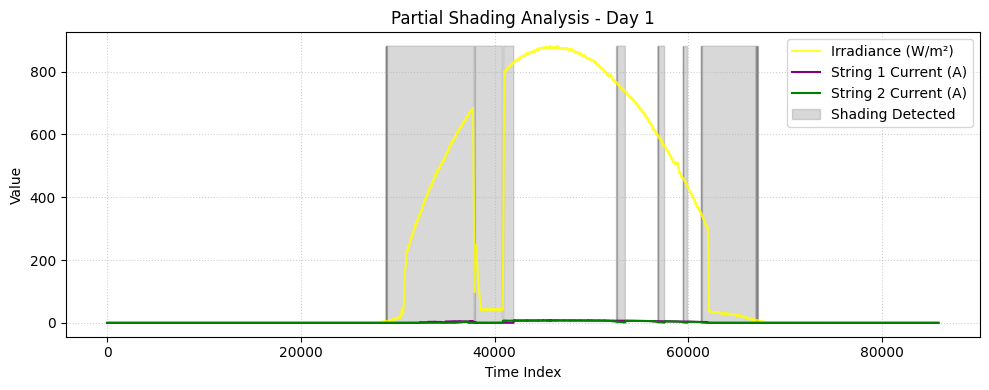

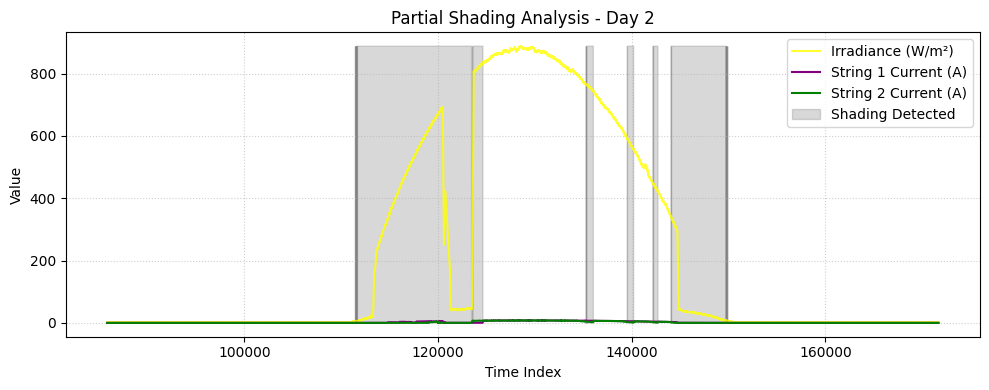

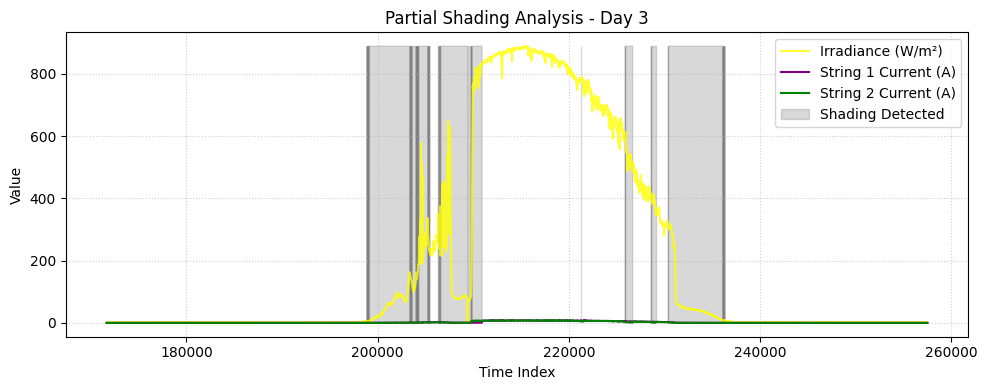

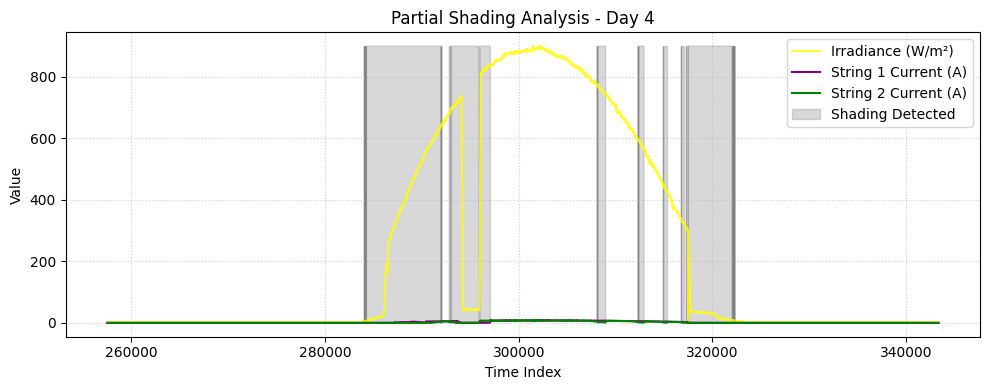

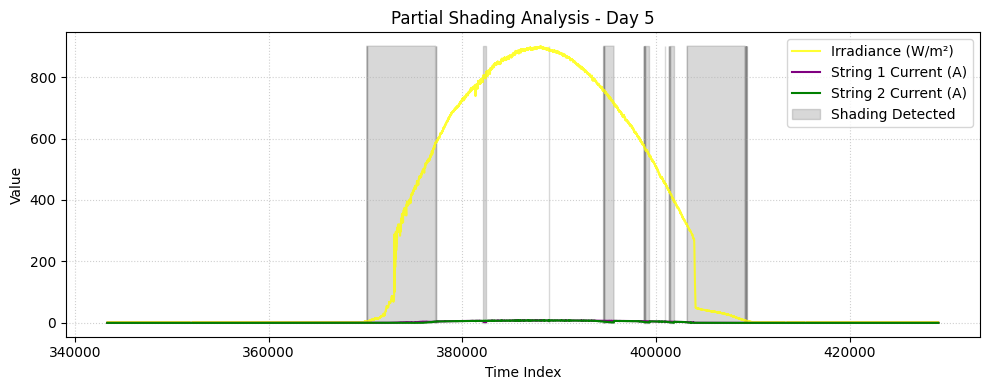

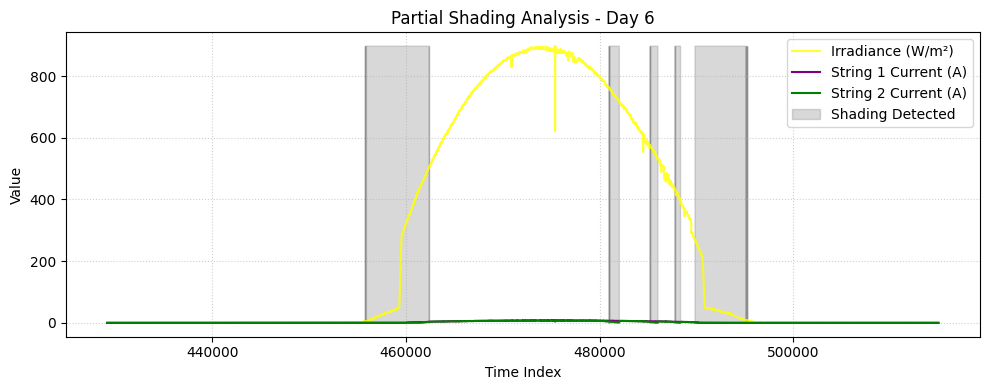

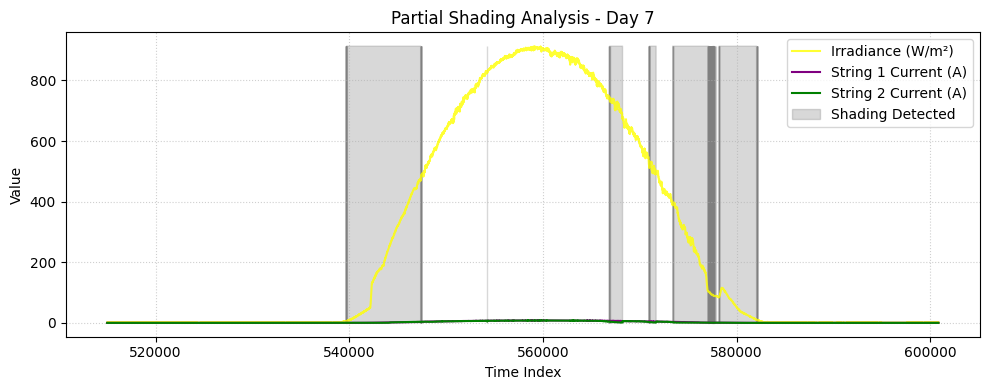

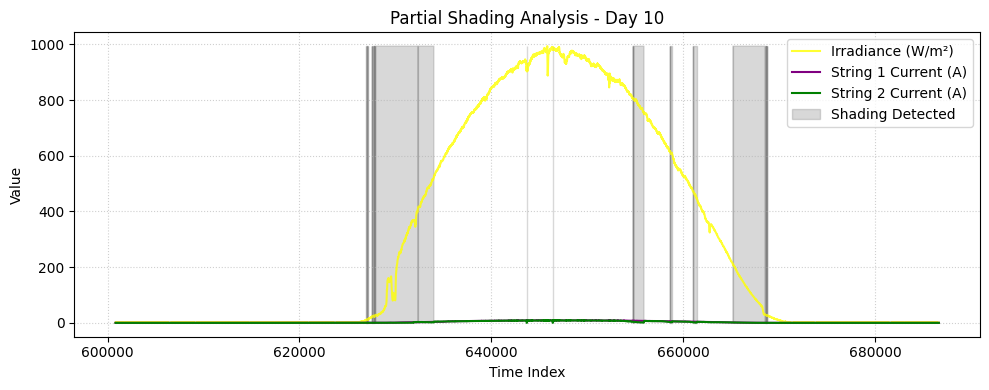

In [7]:
import matplotlib.pyplot as plt
import numpy as np # Added for potential future use or clarity

def highlight_shadowing(day_data, ax, threshold=0.15):
    """
    Highlights regions where current (IDC) drops significantly
    relative to the Irradiance trend.
    """
    # Note: 'day_data' is now a DataFrame for a specific day,
    # so we access columns directly.
    shadow_condition = day_data['idc_total'] < (day_data['expected_idc'] * (1 - threshold))

    ax.fill_between(day_data.index, 0, max(day_data['idc_total'].max(), day_data['irr'].max()),
                    where=shadow_condition,
                    color='gray', alpha=0.3, label='Shading Detected')

# --- Start of fix ---

# First, ensure 'idc_total' is available in the main DataFrame
df['idc_total'] = df['idc1'] + df['idc2']

# Calculate a scaling factor for expected_idc from irradiance
# We use non-shadowed periods to estimate the 'ideal' current-to-irradiance ratio.
# To avoid division by zero or very small numbers, filter for irr > 0
non_shadowed_data = df[(df['partial_shadowing'] == 0) & (df['irr'] > 0)]
if not non_shadowed_data.empty:
    idc_to_irr_scaling_factor = non_shadowed_data['idc_total'].mean() / non_shadowed_data['irr'].mean()
else:
    # Fallback if no non-shadowed data or irr is always 0. A default value is used.
    # The choice of 0.1 is an arbitrary placeholder and may need adjustment.
    idc_to_irr_scaling_factor = 0.1

# Add 'expected_idc' to the DataFrame
df['expected_idc'] = df['irr'] * idc_to_irr_scaling_factor

# Group the DataFrame by 'day' to create the 'days' iterable
days_grouped = df.groupby('day')

# --- End of fix ---

for i, (day_label, day_df) in enumerate(days_grouped):
    plt.figure(figsize=(10, 4))
    ax = plt.gca()

    # The plotting code expects the 'day' object to have attributes like 'timestamp', 'irr', etc.
    # We will pass the day_df directly to highlight_shadowing and use its columns.
    # For timestamp, we'll use the DataFrame's index. If the index is not meaningful
    # as time, a simple numerical sequence could be used. For now, assume index.

    # 1. Plot Irradiance
    plt.plot(day_df.index, day_df.irr, color='yellow', label='Irradiance (W/m²)', alpha=0.8)

    # 2. Plot String Currents
    plt.plot(day_df.index, day_df.idc1, color='purple', label='String 1 Current (A)')

    plt.plot(day_df.index, day_df.idc2, color='green', label='String 2 Current (A)')

    # 3. Apply Highlight Logic
    # Pass the day_df directly
    highlight_shadowing(day_df, ax)

    plt.title(f'Partial Shading Analysis - Day {day_label}') # Use day_label from groupby
    plt.xlabel('Time Index') # Changed label to reflect index use
    plt.ylabel('Value')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()